# Stats in Python

**Focus:** Data representation and interaction, hypothesis testing, linear models, and statistical visualization.

This notebook begins with loading and exploring tabular data using pandas, then builds toward statistical tests and models.

**Dataset:** `brain_size.csv` — brain size and IQ measurements (Willerman et al.).

## 1. Data representation and interaction

### Data as a table — the pandas DataFrame

We load `brain_size.csv` into a pandas DataFrame. The file uses semicolons as separators and represents missing values with `.`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns
import pymc as pm
import arviz as az
import bambi as bmb

# Load the brain size data; treat "." as missing
# index_col=0 uses the first column as the row index
data = pd.read_csv("brain_size.csv", sep=";", na_values=".", index_col=0)
data.head()

g++ not available, if using conda: `conda install gxx`


,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
1,Female,133,132,124,118.0,64.5,816932
2,Male,140,150,124,NaN,72.5,1001121
3,Male,139,123,150,143.0,73.3,1038437
4,Male,133,129,128,172.0,68.8,965353
5,Female,137,132,134,147.0,65.0,951545


### Inspect the DataFrame

Check shape, column types, and a quick summary of the numeric variables.

In [2]:
print("Shape:", data.shape)
print("\nColumn types:")
print(data.dtypes)
print("\nSummary statistics:")
data.describe()

Shape: (40, 7)

Column types:
Gender           str
FSIQ           int64
VIQ            int64
PIQ            int64
Weight       float64
Height       float64
MRI_Count      int64
dtype: object

Summary statistics:


,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
count,40.000000,40.000000,40.00000,38.000000,39.000000,4.000000e+01
mean,113.450000,112.350000,111.02500,151.052632,68.525641,9.087550e+05
std,24.082071,23.616107,22.47105,23.478509,3.994649,7.228205e+04
min,77.000000,71.000000,72.00000,106.000000,62.000000,7.906190e+05
25%,89.750000,90.000000,88.25000,135.250000,66.000000,8.559185e+05
50%,116.500000,113.000000,115.00000,146.500000,68.000000,9.053990e+05
75%,135.500000,129.750000,128.00000,172.000000,70.500000,9.500780e+05
max,144.000000,150.000000,150.00000,192.000000,77.000000,1.079549e+06


### Mean VIQ for the full population

**VIQ** is Verbal IQ. Here is the mean across all subjects.

In [3]:
mean_viq = data["VIQ"].mean()
print(f"Mean VIQ (full population): {mean_viq:.2f}")

Mean VIQ (full population): 112.35


### Number of males and females

In [4]:
gender_counts = data["Gender"].value_counts()
print("Number of males and females:")
print(gender_counts)
print(f"\nTotal males:   {gender_counts.get('Male', 0)}")
print(f"Total females: {gender_counts.get('Female', 0)}")

Number of males and females:
Gender
Female    20
Male      20
Name: count, dtype: int64

Total males:   20
Total females: 20


### Grouping by gender

`groupby` splits the DataFrame by Gender so we can compute group-wise summaries (means, counts, etc.).

In [5]:
groupby_gender = data.groupby("Gender")
groupby_gender

In [6]:
# Mean of each numeric column by gender
groupby_gender.mean(numeric_only=True)

,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
Gender,,,,,,
Female,111.9,109.45,110.45,137.200000,65.765000,862654.6
Male,115.0,115.25,111.60,166.444444,71.431579,954855.4


In [7]:
# Mean VIQ by gender
print("Mean VIQ by gender:")
print(groupby_gender["VIQ"].mean())

Mean VIQ by gender:
Gender
Female    109.45
Male      115.25
Name: VIQ, dtype: float64


### Scatter matrices

A scatter matrix (pair plot of numeric variables) shows pairwise relationships. We plot:
1. **Combined** — all subjects
2. **Male only**
3. **Female only**

Variables used: `VIQ`, `PIQ`, `FSIQ`, and `MRI_Count`.

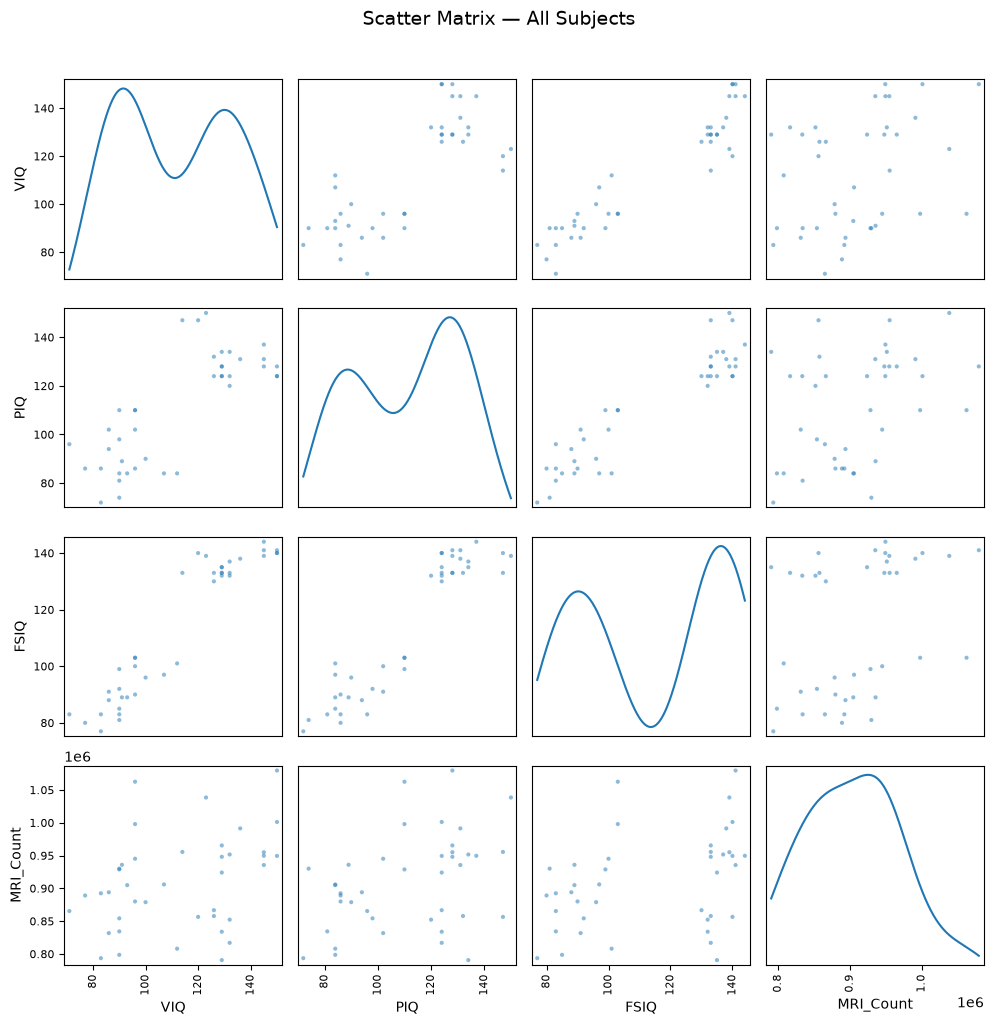

In [8]:
# Combined scatter matrix (all subjects)
scatter_cols = ["VIQ", "PIQ", "FSIQ", "MRI_Count"]

scatter_matrix(
    data[scatter_cols],
    figsize=(10, 10),
    diagonal="kde",
)
plt.suptitle("Scatter Matrix — All Subjects", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

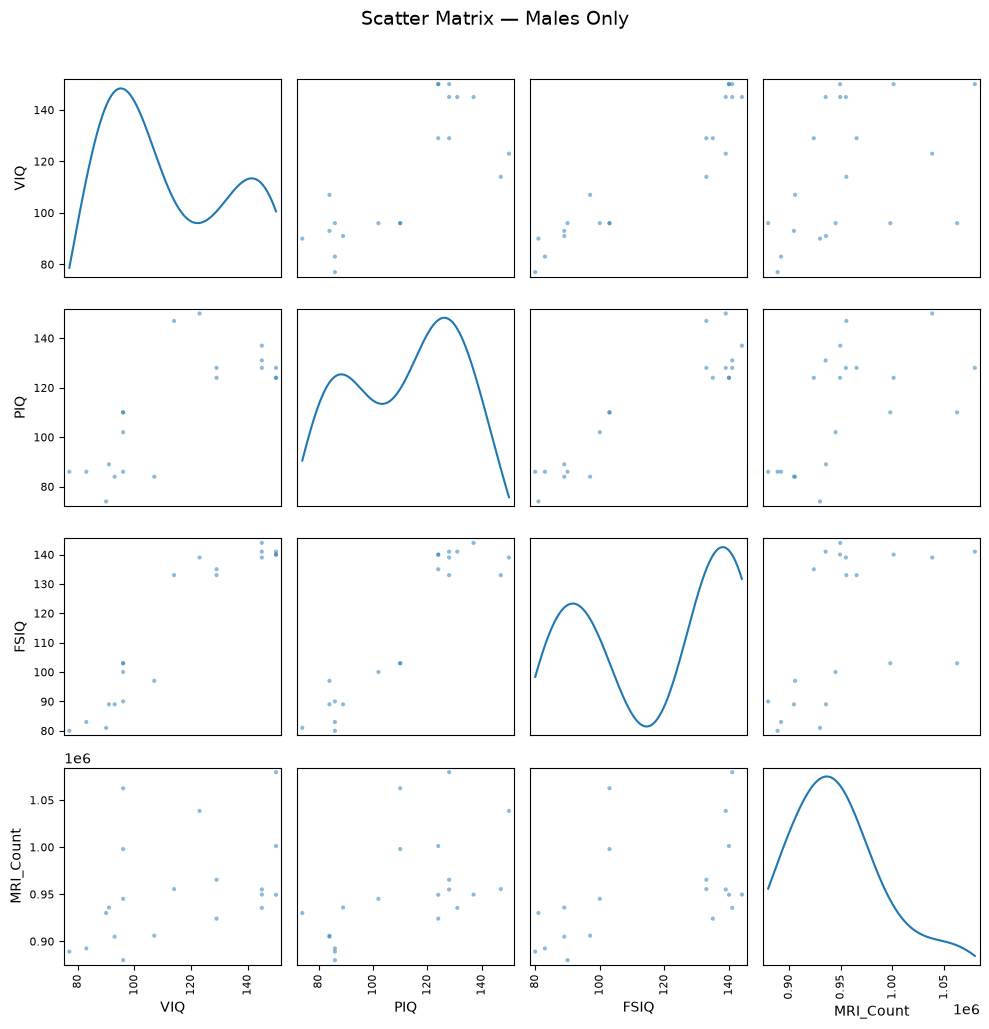

In [9]:
# Male-only scatter matrix
male_data = data[data["Gender"] == "Male"]

scatter_matrix(
    male_data[scatter_cols],
    figsize=(10, 10),
    diagonal="kde",
)
plt.suptitle("Scatter Matrix — Males Only", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

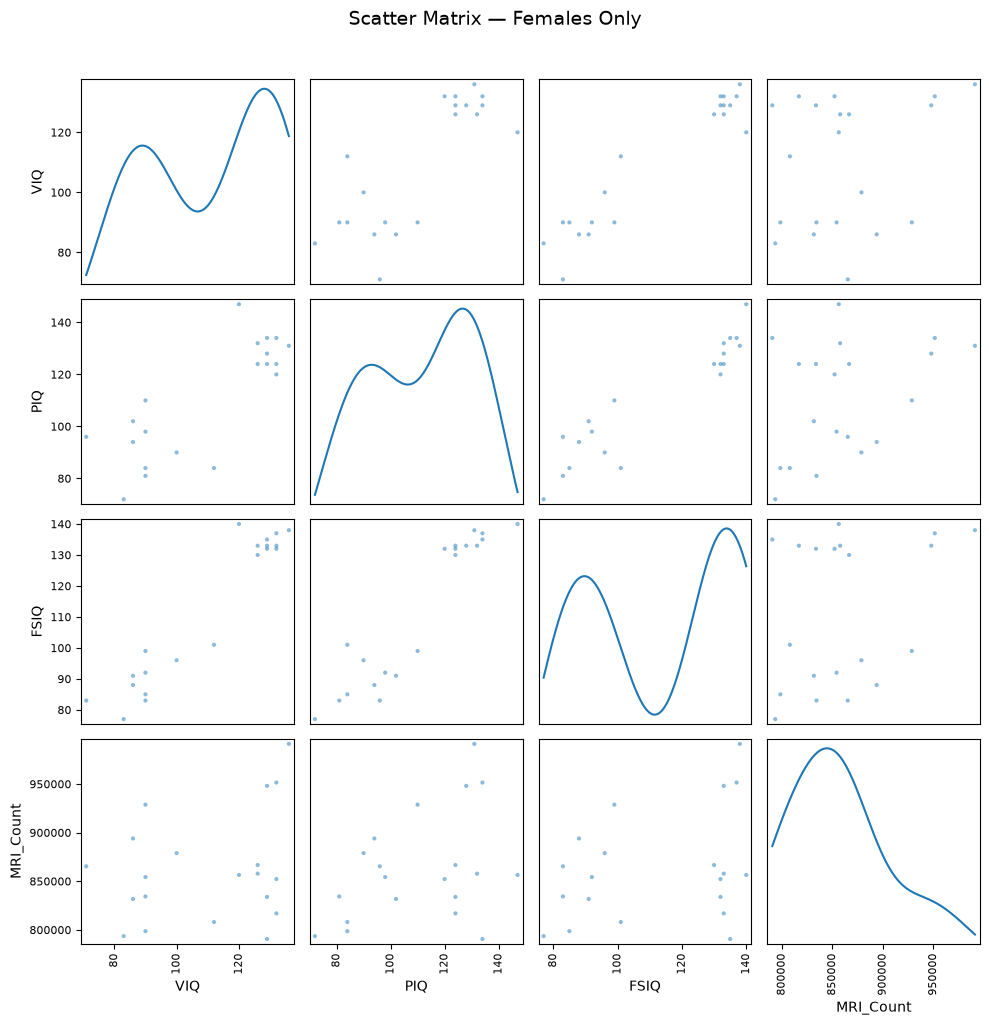

In [10]:
# Female-only scatter matrix
female_data = data[data["Gender"] == "Female"]

scatter_matrix(
    female_data[scatter_cols],
    figsize=(10, 10),
    diagonal="kde",
)
plt.suptitle("Scatter Matrix — Females Only", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---

## 2. Hypothesis testing: comparing two groups

Student’s t-test is the simplest parametric test for whether two means differ. We also use a **paired** t-test when the same individuals contribute both measurements, and a **non-parametric** alternative when normality assumptions may not hold.

### Paired test: are FSIQ and PIQ significantly different?

Full Scale IQ (`FSIQ`) and Performance IQ (`PIQ`) are measured on the **same** subjects, so we use a **paired** (related-samples) t-test.

**H₀:** mean(FSIQ − PIQ) = 0

In [11]:
# Paired t-test: FSIQ vs PIQ on the same individuals
fsiq_piq_ttest = stats.ttest_rel(data["FSIQ"], data["PIQ"])

print("Paired t-test: FSIQ vs PIQ")
print(f"  t-statistic = {fsiq_piq_ttest.statistic:.4f}")
print(f"  p-value     = {fsiq_piq_ttest.pvalue:.4f}")
print(f"  df          = {fsiq_piq_ttest.df}")

if fsiq_piq_ttest.pvalue < 0.05:
    print("\nResult: FSIQ and PIQ differ significantly (reject H0).")
else:
    print("\nResult: No significant difference between FSIQ and PIQ (fail to reject H0).")

Paired t-test: FSIQ vs PIQ
  t-statistic = 1.7842
  p-value     = 0.0822
  df          = 39

Result: No significant difference between FSIQ and PIQ (fail to reject H0).


### Two-sample t-test: is mean VIQ different between males and females?

Males and females are **independent** groups, so we use an unpaired (two-sample) Student’s t-test.

**H₀:** mean VIQ (male) = mean VIQ (female)

In [12]:
female_viq = data[data["Gender"] == "Female"]["VIQ"]
male_viq = data[data["Gender"] == "Male"]["VIQ"]

print(f"Mean female VIQ: {female_viq.mean():.2f}")
print(f"Mean male VIQ:   {male_viq.mean():.2f}")

viq_ttest = stats.ttest_ind(male_viq, female_viq)

print("\nTwo-sample t-test: male VIQ vs female VIQ")
print(f"  t-statistic = {viq_ttest.statistic:.4f}")
print(f"  p-value     = {viq_ttest.pvalue:.4f}")

if viq_ttest.pvalue < 0.05:
    print("\nResult: Mean VIQ differs significantly by gender (reject H0).")
else:
    print("\nResult: No significant difference in mean VIQ by gender (fail to reject H0).")

Mean female VIQ: 109.45
Mean male VIQ:   115.25

Two-sample t-test: male VIQ vs female VIQ
  t-statistic = 0.7726
  p-value     = 0.4445

Result: No significant difference in mean VIQ by gender (fail to reject H0).


### Two-sample t-test: weight difference between males and females

Weight has a few missing values, so we drop NaNs before testing.

**H₀:** mean weight (male) = mean weight (female)

In [13]:
female_weight = data[data["Gender"] == "Female"]["Weight"].dropna()
male_weight = data[data["Gender"] == "Male"]["Weight"].dropna()

print(f"Mean female weight: {female_weight.mean():.2f} (n={len(female_weight)})")
print(f"Mean male weight:   {male_weight.mean():.2f} (n={len(male_weight)})")

weight_ttest = stats.ttest_ind(male_weight, female_weight)

print("\nTwo-sample t-test: male weight vs female weight")
print(f"  t-statistic = {weight_ttest.statistic:.4f}")
print(f"  p-value     = {weight_ttest.pvalue:.6f}")

if weight_ttest.pvalue < 0.05:
    print("\nResult: Mean weight differs significantly by gender (reject H0).")
else:
    print("\nResult: No significant difference in mean weight by gender (fail to reject H0).")

Mean female weight: 137.20 (n=20)
Mean male weight:   166.44 (n=18)

Two-sample t-test: male weight vs female weight
  t-statistic = 4.8710
  p-value     = 0.000022

Result: Mean weight differs significantly by gender (reject H0).


### Non-parametric test: VIQ in males vs females

The Mann–Whitney U test (Wilcoxon rank-sum) does **not** assume normality. It tests whether the VIQ distributions for males and females differ in location (stochastically).

**H₀:** the VIQ distributions for males and females are the same

In [14]:
# Mann-Whitney U test (non-parametric alternative to the two-sample t-test)
viq_mw = stats.mannwhitneyu(male_viq, female_viq)

print("Mann-Whitney U test: male VIQ vs female VIQ")
print(f"  U-statistic = {viq_mw.statistic:.1f}")
print(f"  p-value     = {viq_mw.pvalue:.4f}")

if viq_mw.pvalue < 0.05:
    print("\nResult: VIQ distributions differ by gender (reject H0).")
else:
    print("\nResult: No significant difference in VIQ by gender (fail to reject H0).")

print("\nNote: this agrees with the parametric t-test above — both find no")
print("significant male/female difference in VIQ.")

Mann-Whitney U test: male VIQ vs female VIQ
  U-statistic = 235.5
  p-value     = 0.3423

Result: No significant difference in VIQ by gender (fail to reject H0).

Note: this agrees with the parametric t-test above — both find no
significant male/female difference in VIQ.


### Summary of hypothesis tests

| Comparison | Test | Finding |
|---|---|---|
| FSIQ vs PIQ (same subjects) | Paired t-test | Not significant (p ≈ 0.08) |
| Male vs female VIQ | Two-sample t-test | Not significant (p ≈ 0.44) |
| Male vs female weight | Two-sample t-test | Significant (p ≪ 0.05) |
| Male vs female VIQ | Mann–Whitney U | Not significant (p ≈ 0.34) |

---

## 3. Linear models, multiple factors, and analysis of variance

We specify statistical models with **formulas** (patsy / statsmodels), fit them by ordinary least squares (OLS), and use F-tests / ANOVA to ask whether factors matter after accounting for other variables.

### 3.1 OLS on brain size data: VIQ ~ Gender

Fit a simple linear model for verbal IQ as a function of gender, then inspect the fitted parameters.

- **Intercept** = mean VIQ for the reference group (Female)
- **Gender[T.Male]** = difference in mean VIQ (Male − Female)

In [15]:
# DataFrame for modeling (same brain_size data loaded above)
brain = data.copy()
brain.head()

,Gender,FSIQ,VIQ,PIQ,Weight,Height,MRI_Count
1,Female,133,132,124,118.0,64.5,816932
2,Male,140,150,124,NaN,72.5,1001121
3,Male,139,123,150,143.0,73.3,1038437
4,Male,133,129,128,172.0,68.8,965353
5,Female,137,132,134,147.0,65.0,951545


In [16]:
# Specify and fit an OLS model with a formula
model_viq = smf.ols("VIQ ~ Gender", data=brain).fit()

print("Model parameters:")
print(model_viq.params)
print("\nParameter details:")
print(model_viq.summary().tables[1])

Model parameters:
Intercept         109.45
Gender[T.Male]      5.80
dtype: float64

Parameter details:
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        109.4500      5.308     20.619      0.000      98.704     120.196
Gender[T.Male]     5.8000      7.507      0.773      0.445      -9.397      20.997


### 3.2 Compare IQ types (FSIQ, VIQ, PIQ) between males and females

**FSIQ** is general (full-scale) IQ; **VIQ** and **PIQ** are verbal and performance subscales. We reshape to long form and fit one model with gender and IQ type as factors.

In [17]:
# Long-form table: one row per subject × IQ type
iq_long = pd.melt(
    brain,
    id_vars=["Gender"],
    value_vars=["FSIQ", "VIQ", "PIQ"],
    var_name="IQ_type",
    value_name="IQ",
)
iq_long.head()

,Gender,IQ_type,IQ
0,Female,FSIQ,133
1,Male,FSIQ,140
2,Male,FSIQ,139
3,Male,FSIQ,133
4,Female,FSIQ,137


In [18]:
# Means by gender and IQ type
print(iq_long.groupby(["Gender", "IQ_type"])["IQ"].mean().unstack())

# OLS: IQ ~ Gender + IQ_type  (main effects)
model_iq_types = smf.ols("IQ ~ Gender + C(IQ_type)", data=iq_long).fit()
print("\nParameters:")
print(model_iq_types.params)
print("\nANOVA (Type II):")
print(sm.stats.anova_lm(model_iq_types, typ=2))

IQ_type   FSIQ     PIQ     VIQ
Gender                        
Female   111.9  110.45  109.45
Male     115.0  111.60  115.25

Parameters:
Intercept            111.775
Gender[T.Male]         3.350
C(IQ_type)[T.PIQ]     -2.425
C(IQ_type)[T.VIQ]     -1.100
dtype: float64

ANOVA (Type II):
               sum_sq     df         F    PR(>F)
Gender        336.675    1.0  0.612854  0.435311
C(IQ_type)    117.950    2.0  0.107353  0.898298
Residual    63725.300  116.0       NaN       NaN


In [19]:
# Separate OLS for each IQ measure: gender effect on FSIQ, VIQ, and PIQ
for iq_col in ["FSIQ", "VIQ", "PIQ"]:
    m = smf.ols(f"{iq_col} ~ Gender", data=brain).fit()
    coef = m.params["Gender[T.Male]"]
    pval = m.pvalues["Gender[T.Male]"]
    print(f"{iq_col}: Male−Female = {coef:6.2f},  p = {pval:.4f}")

FSIQ: Male−Female =   3.10,  p = 0.6894
VIQ: Male−Female =   5.80,  p = 0.4445
PIQ: Male−Female =   1.15,  p = 0.8739


### 3.3 Iris data: size relationship and species effect

**Question:** Sepal and petal size tend to be related — bigger flowers are bigger. Is there *in addition* a systematic effect of species?

We model petal width as a function of sepal width (size) and species name.

In [20]:
iris = pd.read_csv("iris.csv")
print(iris.head())
print("\nSpecies:", iris["name"].unique())
print("Shape:", iris.shape)

   sepal_length  sepal_width  petal_length  petal_width    name
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species: <ArrowStringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str
Shape: (150, 5)


In [21]:
# Petal width ~ sepal width (size) + species
iris_model = smf.ols("petal_width ~ sepal_width + C(name)", data=iris).fit()

print("Parameters:")
print(iris_model.params)
print("\n", iris_model.summary().tables[1])
print("\nANOVA (Type II) — is there a species effect after accounting for sepal width?")
print(sm.stats.anova_lm(iris_model, typ=2))

Parameters:
Intercept               -0.741813
C(name)[T.versicolor]    1.268895
C(name)[T.virginica]     1.910058
sepal_width              0.288418
dtype: float64

                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.7418      0.152     -4.891      0.000      -1.042      -0.442
C(name)[T.versicolor]     1.2689      0.046     27.643      0.000       1.178       1.360
C(name)[T.virginica]      1.9101      0.041     46.588      0.000       1.829       1.991
sepal_width               0.2884      0.044      6.594      0.000       0.202       0.375

ANOVA (Type II) — is there a species effect after accounting for sepal width?
                sum_sq     df            F        PR(>F)
C(name)      70.989429    2.0  1089.036343  1.826122e-88
sepal_width   1.417055    1.0    43.477587  7.334086e-10
Residual      4.758545  146.0          NaN    

### F-test: versicolor vs virginica after removing sepal-width effect

After controlling for sepal width, do **versicolor** and **virginica** still differ in petal width?

We test the linear contrast:  
`C(name)[T.versicolor] − C(name)[T.virginica] = 0`

Parameter order in the model: Intercept, C(name)[T.versicolor], C(name)[T.virginica], sepal_width → contrast `[0, 1, -1, 0]`.

In [22]:
# Confirm parameter order for the contrast
print("Parameter names:", list(iris_model.params.index))

# F-test: versicolor vs virginica after removing sepal_width effect
ftest = iris_model.f_test([0, 1, -1, 0])
print("\nF-test: versicolor vs virginica (controlling for sepal_width)")
print(ftest)

p = float(np.asarray(ftest.pvalue).ravel()[0])
if p < 0.05:
    print(f"\nResult: Significant difference (p = {p:.4g}).")
else:
    print(f"\nResult: No significant difference (p = {p:.4g}).")

Parameter names: ['Intercept', 'C(name)[T.versicolor]', 'C(name)[T.virginica]', 'sepal_width']

F-test: versicolor vs virginica (controlling for sepal_width)
<F test: F=297.17307875895585, p=5.038186896143516e-37, df_denom=146, df_num=1>

Result: Significant difference (p = 5.038e-37).


### 3.4 Back to brain size: VIQ by gender after removing brain size, height, and weight

**Question:** Are male and female VIQ different *after accounting for* MRI brain size, height, and weight?

This is multiple regression / ANCOVA. Rows with missing Weight or Height are dropped.

In [23]:
brain_complete = brain.dropna(subset=["Weight", "Height", "MRI_Count", "VIQ"])
print(f"Rows used (complete cases): {len(brain_complete)} / {len(brain)}")

model_viq_adj = smf.ols(
    "VIQ ~ Gender + MRI_Count + Height + Weight",
    data=brain_complete,
).fit()

print("\nParameters:")
print(model_viq_adj.params)
print("\n", model_viq_adj.summary().tables[1])
print("\nANOVA (Type II):")
print(sm.stats.anova_lm(model_viq_adj, typ=2))

gender_p = model_viq_adj.pvalues["Gender[T.Male]"]
print(f"\nGender effect on VIQ after adjusting for MRI_Count, Height, Weight:")
print(f"  Male−Female coefficient = {model_viq_adj.params['Gender[T.Male]']:.2f}")
print(f"  p-value = {gender_p:.4f}")
if gender_p < 0.05:
    print("  Result: Significant gender difference remains after adjustment.")
else:
    print("  Result: No significant gender difference after adjustment.")

Rows used (complete cases): 38 / 40

Parameters:
Intercept         169.771886
Gender[T.Male]     10.157882
MRI_Count           0.000161
Height             -2.733686
Weight             -0.142724
dtype: float64

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        169.7719     90.054      1.885      0.068     -13.443     352.987
Gender[T.Male]    10.1579     10.891      0.933      0.358     -12.001      32.317
MRI_Count          0.0002   6.48e-05      2.489      0.018    2.94e-05       0.000
Height            -2.7337      1.410     -1.938      0.061      -5.603       0.136
Weight            -0.1427      0.215     -0.665      0.511      -0.579       0.294

ANOVA (Type II):
                 sum_sq    df         F    PR(>F)
Gender       385.523419   1.0  0.869846  0.357772
MRI_Count   2745.901172   1.0  6.195503  0.018026
Height      1665.277190   1.0  3.757320  

### Summary — linear models

| Analysis | Finding |
|---|---|
| `VIQ ~ Gender` | Male−Female ≈ 5.8 IQ points; not significant |
| FSIQ / VIQ / PIQ by gender | No significant gender effect for any IQ type |
| Iris: `petal_width ~ sepal_width + species` | Strong species effect after size; sepal width also significant |
| F-test versicolor vs virginica (adj. sepal width) | Significant difference in petal width |
| `VIQ ~ Gender + MRI + Height + Weight` | Gender still not significant after covariates |

---

## 4. More visualization with seaborn

Seaborn is built for statistical exploration. We use the CPS wages data (`wages.txt`) to draw a **pairplot** (scatter matrix) and an **lmplot** (univariate regression of wage on education).

### Load the wages data

`wages.txt` begins with a text description; the numeric table starts afterward (534 observations). We skip the header text and assign column names.

In [24]:
wage_cols = [
    "EDUCATION",
    "SOUTH",
    "SEX",
    "EXPERIENCE",
    "UNION",
    "WAGE",
    "AGE",
    "RACE",
    "OCCUPATION",
    "SECTOR",
    "MARR",
]

wages = pd.read_csv(
    "wages.txt",
    sep=r"\s+",
    skiprows=27,
    header=None,
    names=wage_cols,
    nrows=534,  # exclude trailing contact text at end of file
)

print("Shape:", wages.shape)
wages.head()

Shape: (534, 11)


,EDUCATION,SOUTH,SEX,EXPERIENCE,UNION,WAGE,AGE,RACE,OCCUPATION,SECTOR,MARR
0,8,0,1,21,0,5.10,35,2,6,1,1
1,9,0,1,42,0,4.95,57,3,6,1,1
2,12,0,0,1,0,6.67,19,3,6,1,0
3,12,0,0,4,0,4.00,22,3,6,0,0
4,12,0,0,17,0,7.50,35,3,6,0,1


### Pairplot: scatter matrices

`sns.pairplot` shows pairwise relationships among continuous variables. Diagonals show marginal distributions (KDE).

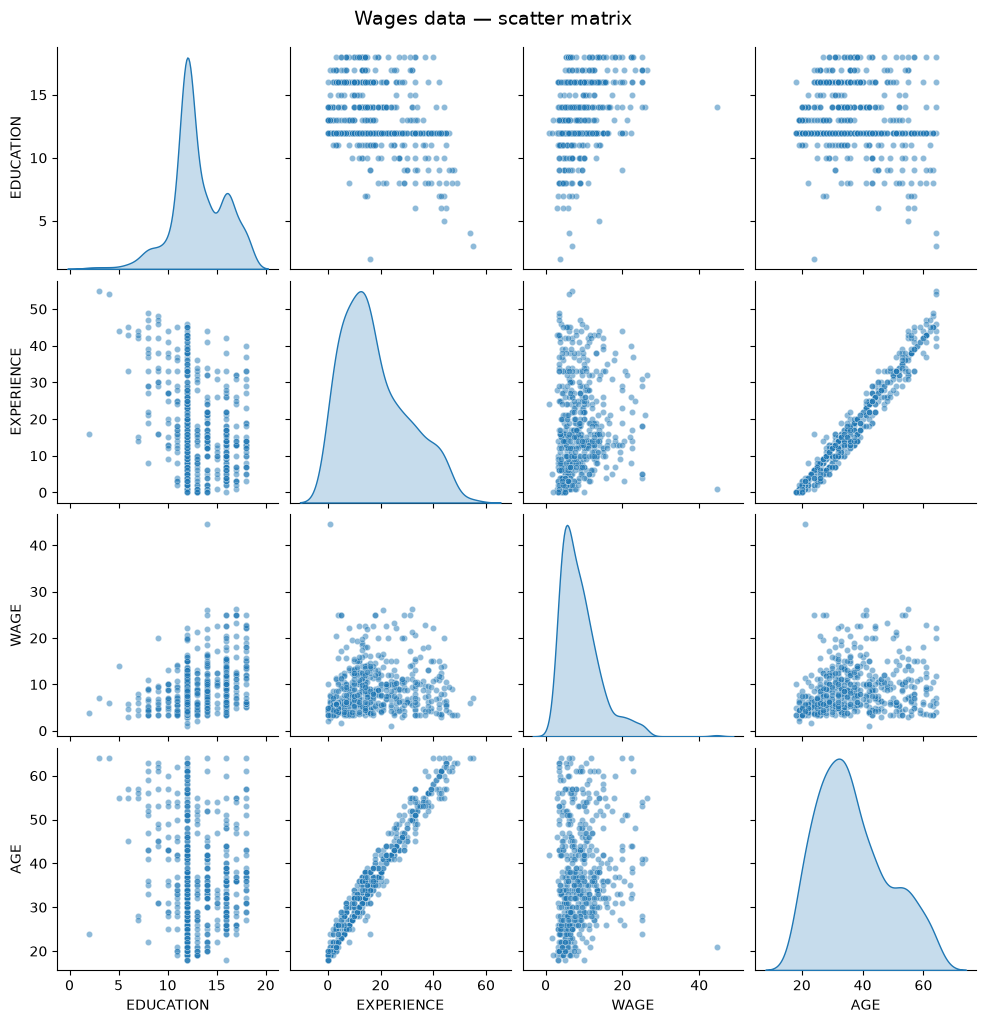

In [25]:
# Scatter matrix of key continuous variables
sns.pairplot(
    wages[["EDUCATION", "EXPERIENCE", "WAGE", "AGE"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
)
plt.suptitle("Wages data — scatter matrix", y=1.02, fontsize=14)
plt.show()

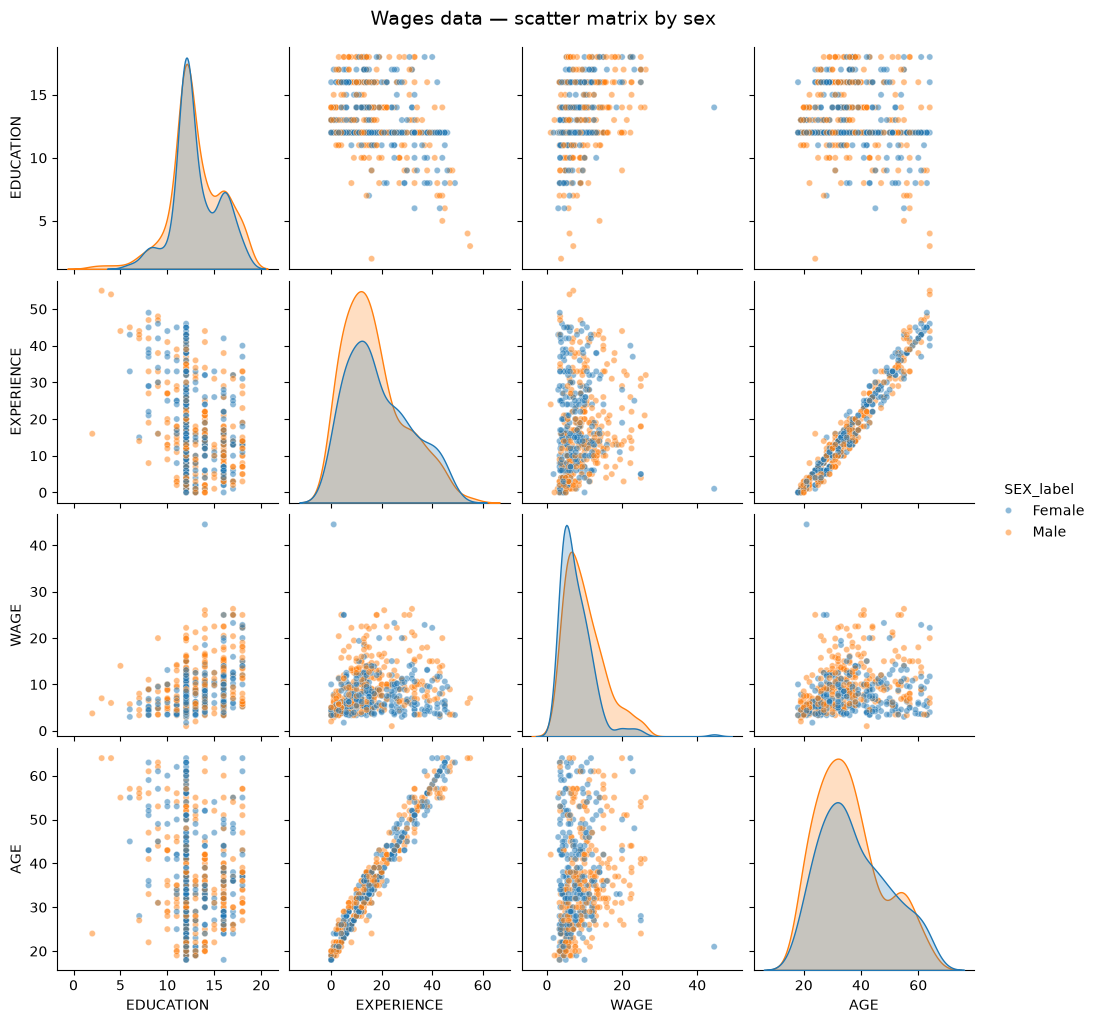

In [26]:
# Same matrix colored by sex (0 = Male, 1 = Female)
wages_plot = wages.copy()
wages_plot["SEX_label"] = wages_plot["SEX"].map({0: "Male", 1: "Female"})

sns.pairplot(
    wages_plot,
    vars=["EDUCATION", "EXPERIENCE", "WAGE", "AGE"],
    hue="SEX_label",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20},
)
plt.suptitle("Wages data — scatter matrix by sex", y=1.02, fontsize=14)
plt.show()

### lmplot: univariate regression of wage on education

`sns.lmplot` scatters the data and overlays a fitted linear regression with a confidence band.

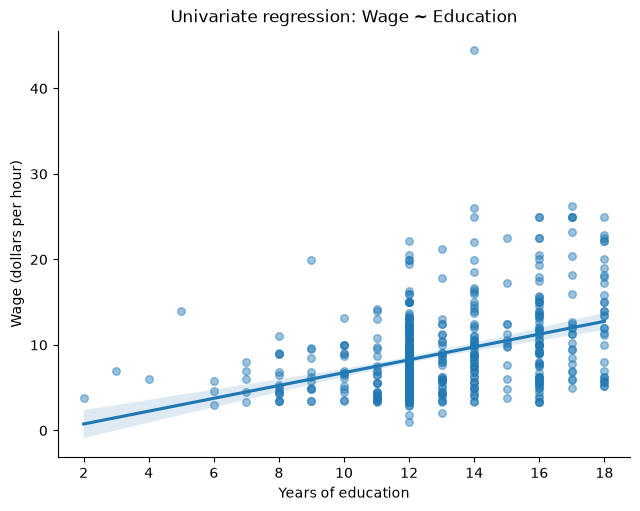

In [27]:
sns.lmplot(
    x="EDUCATION",
    y="WAGE",
    data=wages,
    height=5,
    aspect=1.3,
    scatter_kws={"alpha": 0.45, "s": 30},
)
plt.title("Univariate regression: Wage ~ Education")
plt.xlabel("Years of education")
plt.ylabel("Wage (dollars per hour)")
plt.show()

In [28]:
# Optional: same relationship with a numeric summary via OLS
wage_edu_model = smf.ols("WAGE ~ EDUCATION", data=wages).fit()
print(wage_edu_model.summary().tables[1])
print(f"\nR-squared: {wage_edu_model.rsquared:.3f}")
print(
    f"Each additional year of education is associated with "
    f"${wage_edu_model.params['EDUCATION']:.2f}/hour higher wage "
    f"(p = {wage_edu_model.pvalues['EDUCATION']:.4g})."
)

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.7460      1.045     -0.714      0.476      -2.800       1.308
EDUCATION      0.7505      0.079      9.532      0.000       0.596       0.905

R-squared: 0.146
Each additional year of education is associated with $0.75/hour higher wage (p = 5.474e-20).


### Summary — seaborn exploration

- **Pairplot** shows relationships among education, experience, wage, and age (overall and by sex).
- **lmplot** of wage vs education shows a clear positive linear trend: more education associates with higher hourly wages.

---

## 5. Bayesian alternatives

Frequentist tests give a p-value under a null hypothesis. A **Bayesian** analysis instead places priors on unknowns, updates them with the data, and reports a **posterior** distribution (with credible intervals).

Below we revisit key earlier questions with PyMC / Bambi:
1. Male vs female VIQ
2. Paired FSIQ vs PIQ
3. Male vs female weight
4. VIQ ~ Gender + brain size + height + weight
5. Wage ~ education

### 5.1 Bayesian two-group comparison: VIQ by gender

Model each group mean with a Normal likelihood and shared σ. The quantity of interest is the posterior of  
`diff = μ_male − μ_female`.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_male, mu_female, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                         mean   sd eti89_lb eti89_ub  ess_bulk  ess_tail  \
mu_male                   115  5.5      110      120      1333      1146   
mu_female               109.4  5.5      100      120      1779      1404   
diff_male_minus_female    5.6  7.8     -6.7       18      1641      1540   

                       r_hat mcse_mean mcse_sd  
mu_male                 1.00      0.15    0.12  
mu_female               1.00      0.13   0.094  
diff_male_minus_female  1.00      0.19    0.14  

P(mu_male > mu_female | data) = 0.762
Frequentist two-sample t-test p-value was ≈ 0.44 (no significant difference).


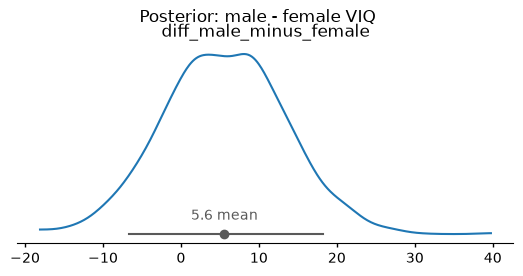

In [29]:
male_viq_arr = data.loc[data["Gender"] == "Male", "VIQ"].to_numpy()
female_viq_arr = data.loc[data["Gender"] == "Female", "VIQ"].to_numpy()

with pm.Model() as viq_bayes:
    mu_male = pm.Normal("mu_male", mu=100, sigma=50)
    mu_female = pm.Normal("mu_female", mu=100, sigma=50)
    sigma = pm.HalfNormal("sigma", sigma=30)

    pm.Normal("obs_male", mu=mu_male, sigma=sigma, observed=male_viq_arr)
    pm.Normal("obs_female", mu=mu_female, sigma=sigma, observed=female_viq_arr)

    diff_viq = pm.Deterministic("diff_male_minus_female", mu_male - mu_female)

    idata_viq = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=42,
        progressbar=False,
    )

print(az.summary(idata_viq, var_names=["mu_male", "mu_female", "diff_male_minus_female"]))

diff_samples = idata_viq.posterior["diff_male_minus_female"].values.ravel()
prob_male_higher = (diff_samples > 0).mean()
print(f"\nP(mu_male > mu_female | data) = {prob_male_higher:.3f}")
print("Frequentist two-sample t-test p-value was ≈ 0.44 (no significant difference).")

az.plot_dist(idata_viq, var_names=["diff_male_minus_female"], backend="matplotlib")
plt.suptitle("Posterior: male - female VIQ", y=1.02)
plt.show()

### 5.2 Bayesian paired comparison: FSIQ vs PIQ

Model the within-subject differences `d_i = FSIQ_i − PIQ_i` and estimate the mean difference μ_d.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_diff, sigma_diff]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


            mean    sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
mu_diff     2.38  1.41     0.13      4.5      1915      1428  1.00     0.033   
sigma_diff  8.89  1.07      7.3       11      1218      1182  1.00     0.031   

           mcse_sd  
mu_diff      0.026  
sigma_diff   0.025  

P(mu_diff > 0 | data) = 0.952
Frequentist paired t-test p-value was ≈ 0.08.


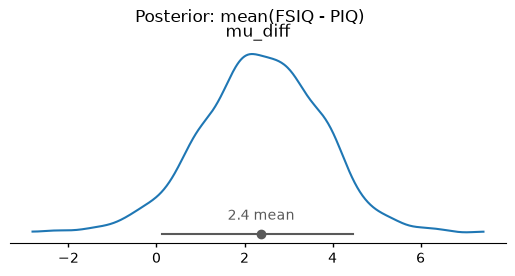

In [30]:
paired_diff = (data["FSIQ"] - data["PIQ"]).to_numpy()

with pm.Model() as paired_bayes:
    mu_d = pm.Normal("mu_diff", mu=0, sigma=20)
    sigma_d = pm.HalfNormal("sigma_diff", sigma=20)
    pm.Normal("obs_diff", mu=mu_d, sigma=sigma_d, observed=paired_diff)

    idata_paired = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=42,
        progressbar=False,
    )

print(az.summary(idata_paired, var_names=["mu_diff", "sigma_diff"]))
mu_samples = idata_paired.posterior["mu_diff"].values.ravel()
print(f"\nP(mu_diff > 0 | data) = {(mu_samples > 0).mean():.3f}")
print("Frequentist paired t-test p-value was ≈ 0.08.")

az.plot_dist(idata_paired, var_names=["mu_diff"], backend="matplotlib")
plt.suptitle("Posterior: mean(FSIQ - PIQ)", y=1.02)
plt.show()

### 5.3 Bayesian two-group comparison: weight by gender

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [mu_male, mu_female, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                         mean   sd eti89_lb eti89_ub  ess_bulk  ess_tail  \
mu_male                 166.3  4.5      160      170      1630      1368   
mu_female               137.5  4.2      130      140      1817      1391   
diff_male_minus_female   28.7  6.3       19       38      1690      1405   

                       r_hat mcse_mean mcse_sd  
mu_male                 1.00      0.11   0.077  
mu_female               1.00     0.099   0.069  
diff_male_minus_female  1.00      0.15    0.11  

P(mu_male > mu_female | data) = 1.000
Frequentist weight t-test was highly significant (p ≈ 2e-5).


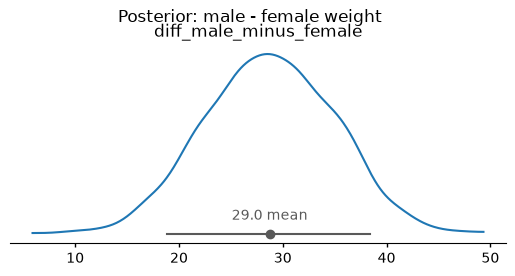

In [31]:
male_w = data.loc[data["Gender"] == "Male", "Weight"].dropna().to_numpy()
female_w = data.loc[data["Gender"] == "Female", "Weight"].dropna().to_numpy()

with pm.Model() as weight_bayes:
    mu_male = pm.Normal("mu_male", mu=150, sigma=40)
    mu_female = pm.Normal("mu_female", mu=150, sigma=40)
    sigma = pm.HalfNormal("sigma", sigma=30)

    pm.Normal("obs_male", mu=mu_male, sigma=sigma, observed=male_w)
    pm.Normal("obs_female", mu=mu_female, sigma=sigma, observed=female_w)

    pm.Deterministic("diff_male_minus_female", mu_male - mu_female)

    idata_weight = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=42,
        progressbar=False,
    )

print(az.summary(idata_weight, var_names=["mu_male", "mu_female", "diff_male_minus_female"]))
w_diff = idata_weight.posterior["diff_male_minus_female"].values.ravel()
print(f"\nP(mu_male > mu_female | data) = {(w_diff > 0).mean():.3f}")
print("Frequentist weight t-test was highly significant (p ≈ 2e-5).")

az.plot_dist(idata_weight, var_names=["diff_male_minus_female"], backend="matplotlib")
plt.suptitle("Posterior: male - female weight", y=1.02)
plt.show()

### 5.4 Bayesian multiple regression (formula API via Bambi)

Bayesian counterpart of  
`VIQ ~ Gender + MRI_Count + Height + Weight`.

We inspect the posterior for the Gender coefficient after adjusting for brain size, height, and weight.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma, Intercept, Gender, MRI_Count, Height, Weight]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 7 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


                  mean       sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
Intercept          170       93       23      320      1641      1494  1.00   
Gender[Male]      10.3     11.2     -7.9       28      1527      1476  1.00   
MRI_Count     0.000159  6.6e-05  5.6e-05  0.00026      2001      1458  1.00   
Height           -2.73     1.49     -5.1    -0.35      1713      1485  1.00   
Weight           -0.14    0.219    -0.49     0.21      1634      1510  1.00   

             mcse_mean  mcse_sd  
Intercept          2.3      1.7  
Gender[Male]      0.29     0.21  
MRI_Count      1.5e-06  1.1e-06  
Height           0.036    0.027  
Weight          0.0054   0.0039  

P(Gender[Male] > 0 | data) = 0.820
Frequentist adjusted Gender p-value was ≈ 0.36.


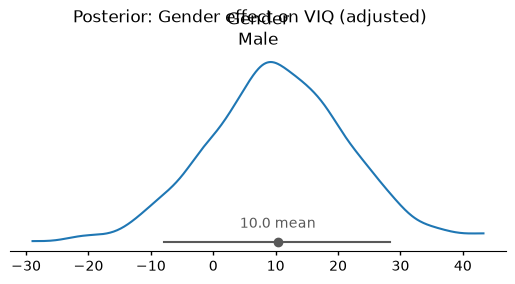

In [32]:
brain_complete = data.dropna(subset=["VIQ", "Gender", "MRI_Count", "Height", "Weight"]).copy()

bayes_lm = bmb.Model(
    "VIQ ~ Gender + MRI_Count + Height + Weight",
    brain_complete,
)
idata_lm = bayes_lm.fit(
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    random_seed=42,
    progressbar=False,
)

print(az.summary(idata_lm, var_names=["Intercept", "Gender", "MRI_Count", "Height", "Weight"]))

gender_post = idata_lm.posterior["Gender"].sel({"Gender_dim": "Male"}).values.ravel()
print(f"\nP(Gender[Male] > 0 | data) = {(gender_post > 0).mean():.3f}")
print("Frequentist adjusted Gender p-value was ≈ 0.36.")

az.plot_dist(idata_lm, var_names=["Gender"], backend="matplotlib")
plt.suptitle("Posterior: Gender effect on VIQ (adjusted)", y=1.05)
plt.show()

### 5.5 Bayesian univariate regression: Wage ~ Education

Bayesian counterpart of the seaborn / OLS wage–education analysis.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma, Intercept, EDUCATION]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 5 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


            mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
Intercept  -0.77   1.06     -2.5     0.99      1967      1306  1.00     0.024   
EDUCATION  0.753  0.079     0.62     0.88      1956      1212  1.00    0.0018   

          mcse_sd  
Intercept   0.017  
EDUCATION  0.0012  

Posterior mean slope ($/hour per year of education): 0.753
P(EDUCATION slope > 0 | data) = 1.000


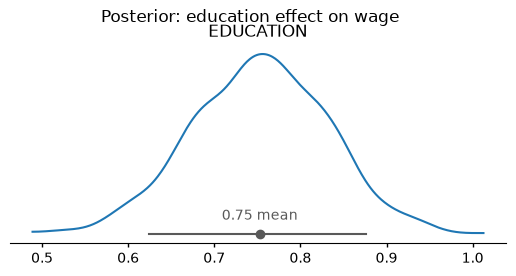

In [33]:
# Reuse wages if already loaded; otherwise load here
if "wages" not in globals():
    wage_cols = [
        "EDUCATION", "SOUTH", "SEX", "EXPERIENCE", "UNION",
        "WAGE", "AGE", "RACE", "OCCUPATION", "SECTOR", "MARR",
    ]
    wages = pd.read_csv(
        "wages.txt", sep=r"\s+", skiprows=27, header=None, names=wage_cols, nrows=534
    )

wage_bayes = bmb.Model("WAGE ~ EDUCATION", wages)
idata_wage = wage_bayes.fit(
    draws=1000,
    tune=1000,
    chains=2,
    target_accept=0.9,
    random_seed=42,
    progressbar=False,
)

print(az.summary(idata_wage, var_names=["Intercept", "EDUCATION"]))
edu_post = idata_wage.posterior["EDUCATION"].values.ravel()
print(f"\nPosterior mean slope ($/hour per year of education): {edu_post.mean():.3f}")
print(f"P(EDUCATION slope > 0 | data) = {(edu_post > 0).mean():.3f}")

az.plot_dist(idata_wage, var_names=["EDUCATION"], backend="matplotlib")
plt.suptitle("Posterior: education effect on wage", y=1.02)
plt.show()

### Summary — Bayesian vs frequentist

| Question | Frequentist | Bayesian posterior |
|---|---|---|
| Male vs female VIQ | t-test p ≈ 0.44 | Diff posterior includes 0; P(male > female) moderate, not decisive |
| FSIQ vs PIQ (paired) | p ≈ 0.08 | μ_diff posterior near 0 with mild mass above 0 |
| Male vs female weight | p ≪ 0.05 | Diff posterior clearly above 0; P(male > female) ≈ 1 |
| VIQ ~ Gender + covariates | Gender p ≈ 0.36 | Gender coefficient posterior overlaps 0 |
| Wage ~ Education | significant positive slope | Education slope posterior clearly > 0 |

**Takeaway:** Bayesian results agree with the frequentist conclusions here, but report uncertainty as full posteriors and probabilities of direction rather than p-values alone.